# AgroScan - Dégel total du backbone

Variante de `jalon2_pipeline_improved.ipynb` avec **dégel complet du backbone** lors de la phase 2.

1. **Phase 1** : même entraînement PlantVillage avec augmentation réaliste (backbone gelé, seule la tête est entraînée).
2. **Phase 2 — dégel total** : toutes les couches du backbone sont dégelées avec un LR très faible (`1e-5`). Permet la plus grande flexibilité d'adaptation, au prix d'un risque accru d'oubli catastrophique (catastrophic forgetting) sur les petits datasets comme PlantDoc (~1 874 images).

> **Avertissement** : avec ~2,5M de paramètres entraînables sur ~1 874 images, l'overfitting et l'oubli catastrophique sont probables. Surveiller attentivement la val_accuracy et s'appuyer sur l'early stopping.

## 1. Lancement du notebook avec le GPU

TensorFlow utilise les bibliothèques CUDA/cuDNN installées dans l'environnement `.venv` par `tensorflow[and-cuda]`. Sur certaines machines, ces bibliothèques ne sont pas trouvées automatiquement par le chargeur dynamique Linux.


## 2. Installation et imports

Installer les dépendances depuis la racine du projet :

```bash
uv pip install -r requirements.txt
```

In [1]:
# %pip install -r ../requirements.txt

In [2]:
import shutil
import subprocess
from pathlib import Path
import json
import time

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import classification_report, confusion_matrix, f1_score, accuracy_score

import tensorflow as tf
import tensorflow_datasets as tfds

print('TensorFlow:', tf.__version__)
print('GPU:', tf.config.list_physical_devices('GPU'))

TensorFlow: 2.20.0
GPU: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


## 3. Configuration du projet

In [3]:
ROOT = Path('..').resolve()
DATA_DIR = ROOT / 'data'
MODEL_DIR = ROOT / 'models'
REPORT_DIR = ROOT / 'reports'

for directory in [DATA_DIR, MODEL_DIR, REPORT_DIR]:
    directory.mkdir(parents=True, exist_ok=True)

IMG_SIZE = (224, 224)
BATCH_SIZE = 32
SEED = 42

# Phase 1 : entraînement PlantVillage (backbone gelé)
EPOCHS_PHASE1 = 5

# Phase 2 : fine-tuning PlantDoc — dégel TOTAL du backbone
# LR plus faible que le dégel partiel (5e-5) pour compenser le plus grand nombre de paramètres.
# Avec 2,5M params sur ~1 874 images, risque d'overfitting élevé.
EPOCHS_PHASE2 = 15        # plus d'epochs pour voir la courbe complète
LR_PHASE2 = 1e-5          # 5× plus faible que le dégel partiel

tf.keras.utils.set_random_seed(SEED)
AUTOTUNE = tf.data.AUTOTUNE

print('Racine projet:', ROOT)

Racine projet: /


## 4. Chargement de PlantVillage et configuration PlantDoc

In [4]:
(train_raw, val_raw, test_raw), info = tfds.load(
    'plant_village',
    split=['train[:70%]', 'train[70%:85%]', 'train[85%:]'],
    as_supervised=True,
    with_info=True,
    data_dir=str(DATA_DIR / 'tfds'),
)

class_names = info.features['label'].names
num_classes = len(class_names)

print('Nombre de classes:', num_classes)
print('Exemples de classes:', class_names[:8])
print(info.splits)

Dl Completed...: 0 url [00:00, ? url/s]

Dl Size...: 0 MiB [00:00, ? MiB/s]

Extraction completed...: 0 file [00:00, ? file/s]

Generating splits...:   0%|          | 0/1 [00:00<?, ? splits/s]

Generating train examples...: 0 examples [00:00, ? examples/s]

Shuffling /data/tfds/plant_village/incomplete.HBRPOI_1.0.2/plant_village-train.tfrecord*...:   0%|          | …

Dataset plant_village downloaded and prepared to /data/tfds/plant_village/1.0.2. Subsequent calls will reuse this data.
Nombre de classes: 38
Exemples de classes: ['Apple___Apple_scab', 'Apple___Black_rot', 'Apple___Cedar_apple_rust', 'Apple___healthy', 'Blueberry___healthy', 'Cherry___healthy', 'Cherry___Powdery_mildew', 'Corn___Cercospora_leaf_spot Gray_leaf_spot']
{Split('train'): <SplitInfo num_examples=54303, num_shards=8>}


In [5]:
PLANTDOC_DIR = DATA_DIR / 'plantdoc'
PLANTDOC_TEST_DIR  = PLANTDOC_DIR / 'test'
PLANTDOC_TRAIN_DIR = PLANTDOC_DIR / 'train'

plantdoc_to_plantvillage = {
    'Apple Scab Leaf':                        'Apple___Apple_scab',
    'Apple leaf':                             'Apple___healthy',
    'Apple rust leaf':                        'Apple___Cedar_apple_rust',
    'Bell_pepper leaf':                       'Pepper,_bell___healthy',
    'Bell_pepper leaf spot':                  'Pepper,_bell___Bacterial_spot',
    'Blueberry leaf':                         'Blueberry___healthy',
    'Cherry leaf':                            'Cherry___healthy',
    'Corn Gray leaf spot':                    'Corn___Cercospora_leaf_spot Gray_leaf_spot',
    'Corn leaf blight':                       'Corn___Northern_Leaf_Blight',
    'Corn rust leaf':                         'Corn___Common_rust',
    'Peach leaf':                             'Peach___healthy',
    'Potato leaf early blight':               'Potato___Early_blight',
    'Potato leaf late blight':                'Potato___Late_blight',
    'Raspberry leaf':                         'Raspberry___healthy',
    'Soyabean leaf':                          'Soybean___healthy',
    'Squash Powdery mildew leaf':             'Squash___Powdery_mildew',
    'Strawberry leaf':                        'Strawberry___healthy',
    'Tomato Early blight leaf':               'Tomato___Early_blight',
    'Tomato Septoria leaf spot':              'Tomato___Septoria_leaf_spot',
    'Tomato leaf':                            'Tomato___healthy',
    'Tomato leaf bacterial spot':             'Tomato___Bacterial_spot',
    'Tomato leaf late blight':                'Tomato___Late_blight',
    'Tomato leaf mosaic virus':               'Tomato___Tomato_mosaic_virus',
    'Tomato leaf yellow virus':               'Tomato___Tomato_Yellow_Leaf_Curl_Virus',
    'Tomato mold leaf':                       'Tomato___Leaf_Mold',
    'Tomato two spotted spider mites leaf':   'Tomato___Spider_mites Two-spotted_spider_mite',
    'grape leaf':                             'Grape___healthy',
    'grape leaf black rot':                   'Grape___Black_rot',
}

if not PLANTDOC_TEST_DIR.exists():
    print('PlantDoc absent — téléchargement depuis GitHub...')
    PLANTDOC_DIR.mkdir(parents=True, exist_ok=True)
    tmp_clone = DATA_DIR / '_plantdoc_clone'
    subprocess.run(
        ['git', 'clone', '--depth', '1',
         'https://github.com/pratikkayal/PlantDoc-Dataset.git',
         str(tmp_clone)],
        check=True,
    )
    for split in ('train', 'test'):
        clone_src = tmp_clone / split
        clone_dst = PLANTDOC_DIR / split
        if clone_src.exists() and not clone_dst.exists():
            shutil.copytree(clone_src, clone_dst)
    shutil.rmtree(tmp_clone)
    print('PlantDoc téléchargé.')

valid_mapping = {}
if PLANTDOC_TEST_DIR.exists():
    plantdoc_classes = sorted([p.name for p in PLANTDOC_TEST_DIR.iterdir() if p.is_dir()])
    valid_mapping = {
        pd_cls: pv_cls for pd_cls, pv_cls in plantdoc_to_plantvillage.items()
        if pd_cls in plantdoc_classes and pv_cls in class_names
    }
    print(f'PlantDoc test  : {len(plantdoc_classes)} classes, {len(valid_mapping)} évaluables')
else:
    print('PlantDoc non trouvé. Placer le dataset dans data/plantdoc/')

PlantDoc absent — téléchargement depuis GitHub...
PlantDoc téléchargé.
PlantDoc test  : 27 classes, 27 évaluables


## 5. Exploration rapide des données

In [6]:
def count_labels(ds):
    counts = np.zeros(num_classes, dtype=int)
    for _, label in tfds.as_numpy(ds):
        counts[int(label)] += 1
    return counts

train_counts = count_labels(train_raw)
val_counts   = count_labels(val_raw)
test_counts  = count_labels(test_raw)

distribution = pd.DataFrame({
    'classe':     class_names,
    'train':      train_counts,
    'validation': val_counts,
    'test':       test_counts,
})
distribution['total'] = distribution[['train', 'validation', 'test']].sum(axis=1)
distribution.sort_values('total', ascending=False).head(10)

,classe,train,validation,test,total
15,Orange___Haunglongbing_(Citrus_greening),3849,826,832,5507
37,Tomato___Tomato_Yellow_Leaf_Curl_Virus,3700,804,853,5357
24,Soybean___healthy,3572,727,791,5090
16,Peach___Bacterial_spot,1609,345,343,2297
28,Tomato___Bacterial_spot,1534,308,285,2127
31,Tomato___Late_blight,1357,270,281,1908
25,Squash___Powdery_mildew,1251,303,281,1835
33,Tomato___Septoria_leaf_spot,1224,285,262,1771
34,Tomato___Spider_mites Two-spotted_spider_mite,1188,238,250,1676
3,Apple___healthy,1139,251,255,1645


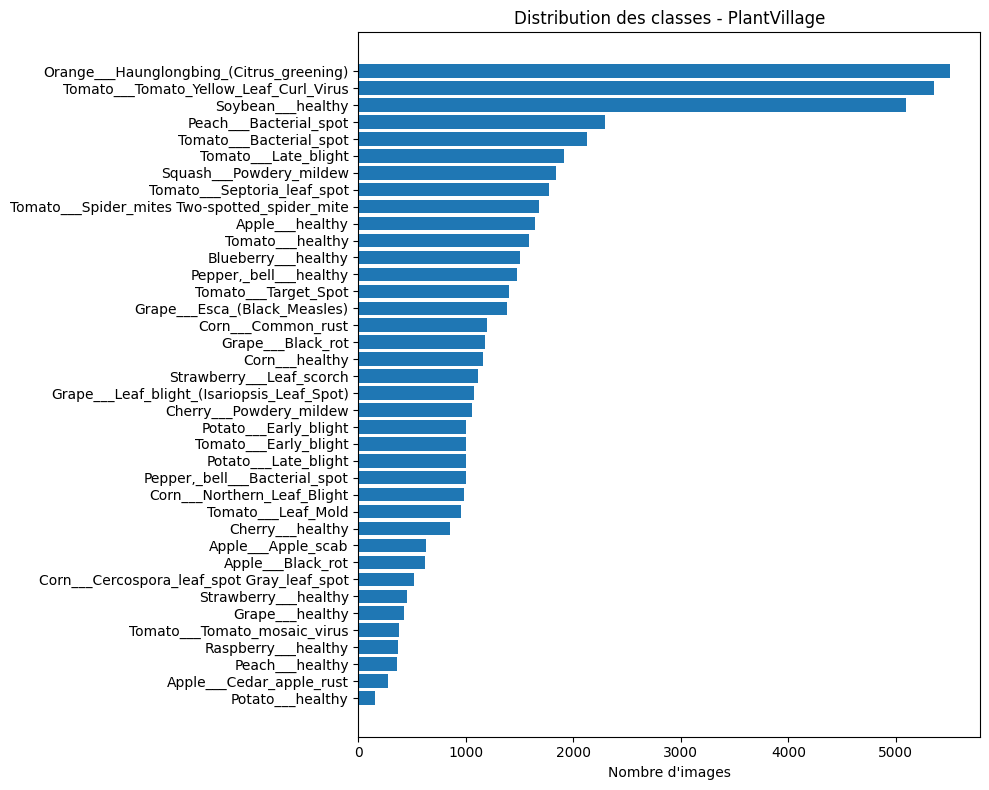

In [7]:
plt.figure(figsize=(10, 8))
plot_df = distribution.sort_values('total', ascending=True)
plt.barh(plot_df['classe'], plot_df['total'])
plt.title('Distribution des classes - PlantVillage')
plt.xlabel("Nombre d'images")
plt.tight_layout()
plt.show()

## 6. Augmentation réaliste et prétraitement

Identique à `jalon2_pipeline_improved.ipynb` : augmentation forte simulant les conditions mobiles terrain (flip vertical, rotation 25°, zoom, variations de luminosité/contraste, bruit gaussien).

In [8]:
data_augmentation = tf.keras.Sequential([
    tf.keras.layers.RandomFlip('horizontal_and_vertical', seed=SEED),
    tf.keras.layers.RandomRotation(0.25, seed=SEED),
    tf.keras.layers.RandomZoom((-0.35, 0.1), seed=SEED),
    tf.keras.layers.RandomContrast(0.4, seed=SEED),
    tf.keras.layers.RandomBrightness(0.2, seed=SEED),
    tf.keras.layers.Lambda(
        lambda x: x + tf.random.normal(tf.shape(x), mean=0.0, stddev=10.0),
        name='gaussian_noise_10',
    ),
], name='data_augmentation_realistic')

def preprocess(image, label, training=False):
    image = tf.image.resize(image, IMG_SIZE)
    image = tf.cast(image, tf.float32)
    if training:
        image = data_augmentation(image, training=True)
    return image, label

train_ds = (
    train_raw
    .shuffle(4096, seed=SEED, reshuffle_each_iteration=False)
    .map(lambda x, y: preprocess(x, y, training=True), num_parallel_calls=AUTOTUNE)
    .batch(BATCH_SIZE)
    .prefetch(AUTOTUNE)
)
val_ds  = val_raw.map(preprocess,  num_parallel_calls=AUTOTUNE).batch(BATCH_SIZE).prefetch(AUTOTUNE)
test_ds = test_raw.map(preprocess, num_parallel_calls=AUTOTUNE).batch(BATCH_SIZE).prefetch(AUTOTUNE)

options = tf.data.Options()
options.deterministic = True
train_ds = train_ds.with_options(options)
val_ds   = val_ds.with_options(options)
test_ds  = test_ds.with_options(options)

## 7. Préparation du dataset PlantDoc pour le fine-tuning

In [9]:
pv_label_to_idx = {name: idx for idx, name in enumerate(class_names)}

ft_image_paths, ft_image_labels = [], []
for pd_cls, pv_cls in plantdoc_to_plantvillage.items():
    cls_train_dir = PLANTDOC_TRAIN_DIR / pd_cls
    if not cls_train_dir.exists() or pv_cls not in class_names:
        continue
    pv_idx = pv_label_to_idx[pv_cls]
    for p in sorted(cls_train_dir.iterdir()):
        if p.is_file():
            ft_image_paths.append(str(p))
            ft_image_labels.append(pv_idx)

rng_ft = np.random.default_rng(SEED)
perm = rng_ft.permutation(len(ft_image_paths))
ft_image_paths  = [ft_image_paths[i]  for i in perm]
ft_image_labels = [ft_image_labels[i] for i in perm]

n_val = int(0.2 * len(ft_image_paths))
ft_val_paths,   ft_val_labels   = ft_image_paths[:n_val],  ft_image_labels[:n_val]
ft_train_paths, ft_train_labels = ft_image_paths[n_val:],  ft_image_labels[n_val:]

print(f'PlantDoc fine-tuning — train : {len(ft_train_paths)} images, val : {len(ft_val_paths)} images')
print(f'Classes représentées : {len(set(ft_image_labels))} / {num_classes}')

def load_image_ft(path, label, augment=False):
    raw = tf.io.read_file(path)
    img = tf.image.decode_image(raw, channels=3, expand_animations=False)
    img.set_shape([None, None, 3])
    img = tf.image.resize(img, IMG_SIZE)
    img = tf.cast(img, tf.float32)
    if augment:
        img = data_augmentation(img, training=True)
    return img, label

ft_train_ds = (
    tf.data.Dataset.from_tensor_slices((ft_train_paths, ft_train_labels))
    .map(lambda p, l: load_image_ft(p, l, augment=True), num_parallel_calls=AUTOTUNE)
    .batch(BATCH_SIZE)
    .prefetch(AUTOTUNE)
)
ft_val_ds = (
    tf.data.Dataset.from_tensor_slices((ft_val_paths, ft_val_labels))
    .map(load_image_ft, num_parallel_calls=AUTOTUNE)
    .batch(BATCH_SIZE)
    .prefetch(AUTOTUNE)
)

PlantDoc fine-tuning — train : 1874 images, val : 468 images
Classes représentées : 28 / 38


## 8. Modèle : MobileNetV3Small

In [10]:
base_model = tf.keras.applications.MobileNetV3Small(
    input_shape=IMG_SIZE + (3,),
    include_top=False,
    weights='imagenet',
    include_preprocessing=True,
)
base_model.trainable = False

inputs  = tf.keras.Input(shape=IMG_SIZE + (3,))
x       = base_model(inputs, training=False)
x       = tf.keras.layers.GlobalAveragePooling2D()(x)
x       = tf.keras.layers.Dropout(0.25)(x)
outputs = tf.keras.layers.Dense(num_classes, activation='softmax')(x)

model = tf.keras.Model(inputs, outputs, name='agroscan_mobilenetv3_full_unfreeze')
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy'],
)

model.summary()

4334752/4334752 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step


Model: "agroscan_mobilenetv3_full_unfreeze"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_2 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ MobileNetV3Small (Functional)   │ (None, 7, 7, 576)      │       939,120 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 576)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 576)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 38)             │        21,926 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 961,046 (3.67 MB)

 Trainable params: 21,926 (85.65 KB)

 Non-trainable params: 939,120 (3.58 MB)

## 9. Phase 1 — Entraînement sur PlantVillage

Le backbone est entièrement gelé. Seule la tête de classification est entraînée, avec l'augmentation réaliste appliquée dès cette phase.

Epoch 1/5
1188/1188 ━━━━━━━━━━━━━━━━━━━━ 589s 480ms/step - accuracy: 0.7473 - loss: 0.9526 - val_accuracy: 0.8673 - val_loss: 0.4862
Epoch 2/5
1188/1188 ━━━━━━━━━━━━━━━━━━━━ 540s 453ms/step - accuracy: 0.8742 - loss: 0.4356 - val_accuracy: 0.8969 - val_loss: 0.3513
Epoch 3/5
1188/1188 ━━━━━━━━━━━━━━━━━━━━ 566s 456ms/step - accuracy: 0.8950 - loss: 0.3503 - val_accuracy: 0.9015 - val_loss: 0.3170
Epoch 4/5
1188/1188 ━━━━━━━━━━━━━━━━━━━━ 569s 462ms/step - accuracy: 0.9045 - loss: 0.3131 - val_accuracy: 0.9007 - val_loss: 0.3162
Epoch 5/5
1188/1188 ━━━━━━━━━━━━━━━━━━━━ 558s 459ms/step - accuracy: 0.9051 - loss: 0.2993 - val_accuracy: 0.9099 - val_loss: 0.2842


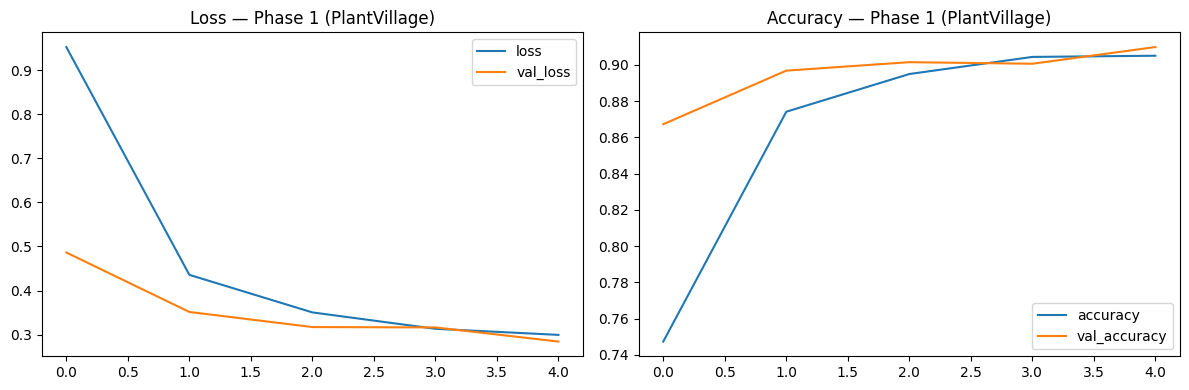

In [11]:
phase1_checkpoint_path = str(MODEL_DIR / 'agroscan_full_unfreeze_phase1.keras')

callbacks_phase1 = [
    tf.keras.callbacks.ModelCheckpoint(
        filepath=phase1_checkpoint_path,
        monitor='val_accuracy',
        save_best_only=True,
    ),
    tf.keras.callbacks.EarlyStopping(
        monitor='val_accuracy',
        patience=2,
        restore_best_weights=True,
    ),
]

history_p1 = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS_PHASE1,
    callbacks=callbacks_phase1,
)

history_p1_df = pd.DataFrame(history_p1.history)
history_p1_df.to_csv(REPORT_DIR / 'full_unfreeze_phase1_history.csv', index=False)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
history_p1_df[['loss', 'val_loss']].plot(ax=axes[0], title='Loss — Phase 1 (PlantVillage)')
history_p1_df[['accuracy', 'val_accuracy']].plot(ax=axes[1], title='Accuracy — Phase 1 (PlantVillage)')
plt.tight_layout()
plt.show()

## 10. Phase 2 — Dégel TOTAL du backbone, fine-tuning sur PlantDoc

**Différence clé vs `jalon2_pipeline_improved.ipynb`** : toutes les couches du backbone sont dégelées, y compris les premières couches extractrices de features bas-niveau.

- **Avantage** : flexibilité maximale d'adaptation au domaine PlantDoc.
- **Risque principal** : avec seulement ~1 874 images d'entraînement pour ~2,5M paramètres entraînables, le modèle peut :
  1. Overfitter rapidement sur PlantDoc (d'où `patience=2` et early stopping agressif)
  2. Oublier les représentations apprises sur PlantVillage (catastrophic forgetting)
- **Mitigation** : LR très faible (`1e-5`) pour que chaque gradient step soit infime. Les couches BatchNormalization restent en mode inférence (backbone appelé avec `training=False`).

Backbone : 157/157 couches dégelerées (100 %)
Paramètres : 961,046 total, 948,934 entraînables (98.7 %)
Ratio images/paramètres : 0.001975 (très faible — surveillance étroite nécessaire)
Epoch 1/15
59/59 ━━━━━━━━━━━━━━━━━━━━ 139s 1s/step - accuracy: 0.0923 - loss: 10.1089 - val_accuracy: 0.1603 - val_loss: 6.5974 - learning_rate: 1.0000e-05
Epoch 2/15
59/59 ━━━━━━━━━━━━━━━━━━━━ 73s 820ms/step - accuracy: 0.0934 - loss: 9.4818 - val_accuracy: 0.1624 - val_loss: 6.1566 - learning_rate: 1.0000e-05
Epoch 3/15
59/59 ━━━━━━━━━━━━━━━━━━━━ 50s 841ms/step - accuracy: 0.0934 - loss: 9.0643 - val_accuracy: 0.1731 - val_loss: 5.7806 - learning_rate: 1.0000e-05
Epoch 4/15
59/59 ━━━━━━━━━━━━━━━━━━━━ 82s 839ms/step - accuracy: 0.0939 - loss: 8.3262 - val_accuracy: 0.1752 - val_loss: 5.4283 - learning_rate: 1.0000e-05
Epoch 5/15
59/59 ━━━━━━━━━━━━━━━━━━━━ 81s 816ms/step - accuracy: 0.0977 - loss: 7.4094 - val_accuracy: 0.1752 - val_loss: 5.1212 - learning_rate: 1.0000e-05
Epoch 6/15
59/59 ━━━━━━━━━━━━

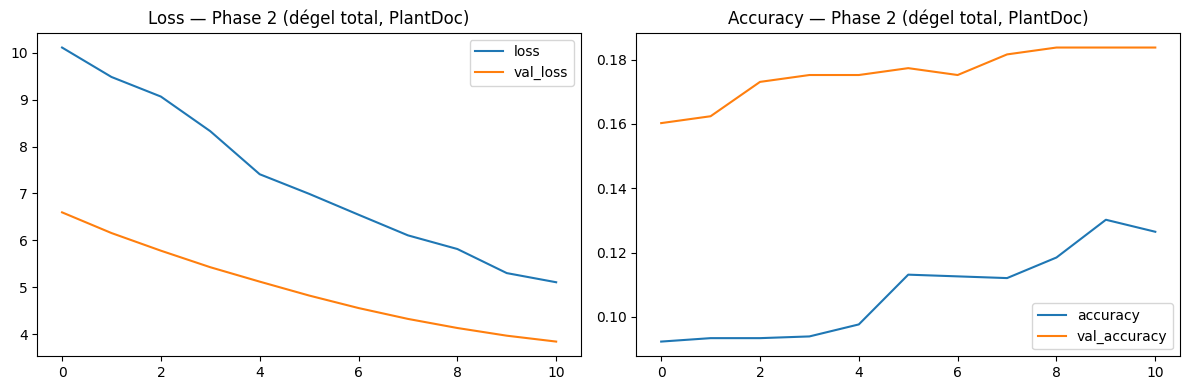

In [12]:
# Dégel TOTAL du backbone (toutes les couches)
backbone = model.layers[1]
backbone.trainable = True

# Les BatchNorm restent en mode inférence car le backbone est appelé avec training=False
n_layers = len(backbone.layers)
n_trainable = sum(1 for l in backbone.layers if l.trainable)
trainable_params = sum(int(np.prod(w.shape)) for w in model.trainable_weights)
total_params = model.count_params()

print(f'Backbone : {n_trainable}/{n_layers} couches dégelerées (100 %)')
print(f'Paramètres : {total_params:,} total, {trainable_params:,} entraînables ({100 * trainable_params / total_params:.1f} %)')
print(f'Ratio images/paramètres : {len(ft_train_paths) / trainable_params:.6f} (très faible — surveillance étroite nécessaire)')

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=LR_PHASE2),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy'],
)

phase2_checkpoint_path = str(MODEL_DIR / 'agroscan_full_unfreeze_phase2.keras')

callbacks_phase2 = [
    tf.keras.callbacks.ModelCheckpoint(
        filepath=phase2_checkpoint_path,
        monitor='val_accuracy',
        save_best_only=True,
    ),
    tf.keras.callbacks.EarlyStopping(
        monitor='val_accuracy',
        patience=2,   # patience courte : stopper dès les premiers signes d'overfitting
        restore_best_weights=True,
    ),
    tf.keras.callbacks.ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.5,
        patience=1,
        min_lr=1e-7,
        verbose=1,
    ),
]

history_p2 = model.fit(
    ft_train_ds,
    validation_data=ft_val_ds,
    epochs=EPOCHS_PHASE2,
    callbacks=callbacks_phase2,
)

history_p2_df = pd.DataFrame(history_p2.history)
history_p2_df.to_csv(REPORT_DIR / 'full_unfreeze_phase2_history.csv', index=False)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
history_p2_df[['loss', 'val_loss']].plot(ax=axes[0], title='Loss — Phase 2 (dégel total, PlantDoc)')
history_p2_df[['accuracy', 'val_accuracy']].plot(ax=axes[1], title='Accuracy — Phase 2 (dégel total, PlantDoc)')
plt.tight_layout()
plt.show()

## 11. Évaluation sur PlantVillage test

> **Indicateur d'oubli catastrophique** : si l'accuracy PlantVillage est nettement inférieure au modèle amélioré (dégel partiel), le dégel total a causé une régression. Comparer aux valeurs de référence : Baseline 94,98 %, Amélioré 71,34 %.

In [14]:
def collect_predictions(model, ds):
    y_true, y_pred, y_proba = [], [], []
    for images, labels in ds:
        proba = model.predict(images, verbose=0)
        y_true.extend(labels.numpy().tolist())
        y_pred.extend(np.argmax(proba, axis=1).tolist())
        y_proba.extend(np.max(proba, axis=1).tolist())
    return np.array(y_true), np.array(y_pred), np.array(y_proba)

y_true_pv, y_pred_pv, y_conf_pv = collect_predictions(model, test_ds)

pv_accuracy = accuracy_score(y_true_pv, y_pred_pv)
pv_f1_macro = f1_score(y_true_pv, y_pred_pv, average='macro')

print(f'PlantVillage — Accuracy : {pv_accuracy:.4f}  |  F1 macro : {pv_f1_macro:.4f}')
print()
print(f'{"":25s}  {"Accuracy":>10s}  {"F1 macro":>10s}')
print(f'{"Baseline":25s}  {0.9498:>10.4f}  {0.9363:>10.4f}')
print(f'{"Amélioré (dégel 25%)":25s}  {0.7134:>10.4f}  {0.6302:>10.4f}')
print(f'{"Dégel total":25s}  {pv_accuracy:>10.4f}  {pv_f1_macro:>10.4f}')

PlantVillage — Accuracy : 0.8043  |  F1 macro : 0.7645

                             Accuracy    F1 macro
Baseline                       0.9498      0.9363
Amélioré (dégel 25%)           0.7134      0.6302
Dégel total                    0.8043      0.7645


In [15]:
report_pv = classification_report(
    y_true_pv, y_pred_pv,
    target_names=class_names,
    output_dict=True,
    zero_division=0,
)
report_pv_df = pd.DataFrame(report_pv).transpose()
report_pv_df.to_csv(REPORT_DIR / 'full_unfreeze_pv_classification_report.csv')
report_pv_df.head()

,precision,recall,f1-score,support
Apple___Apple_scab,0.897959,0.458333,0.606897,96.0
Apple___Black_rot,0.920792,0.869159,0.894231,107.0
Apple___Cedar_apple_rust,0.433735,0.900000,0.585366,40.0
Apple___healthy,0.402536,0.996078,0.573363,255.0
Blueberry___healthy,0.828685,0.976526,0.896552,213.0


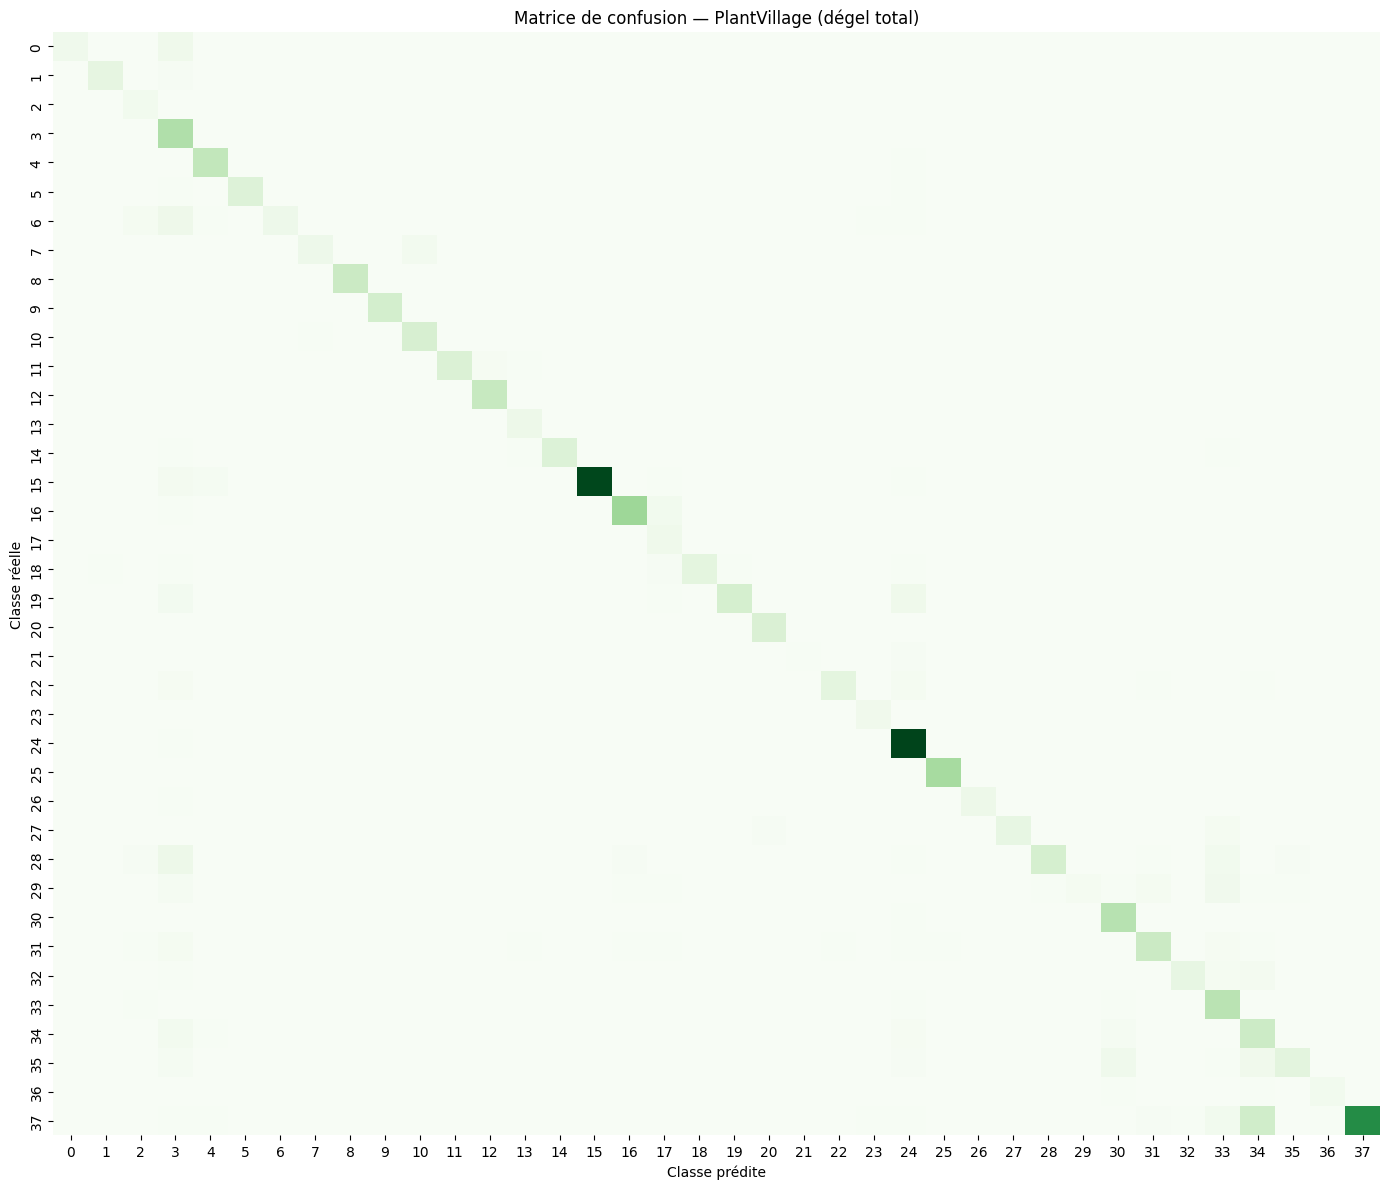

In [16]:
cm = confusion_matrix(y_true_pv, y_pred_pv)
plt.figure(figsize=(14, 12))
sns.heatmap(cm, cmap='Greens', cbar=False)
plt.title('Matrice de confusion — PlantVillage (dégel total)')
plt.xlabel('Classe prédite')
plt.ylabel('Classe réelle')
plt.tight_layout()
plt.savefig(REPORT_DIR / 'full_unfreeze_confusion_matrix.png', dpi=180)
plt.show()

## 12. Évaluation sur PlantDoc test

Métrique principale. Comparaison directe avec la baseline et le modèle amélioré.

In [17]:
plantdoc_test = tf.keras.utils.image_dataset_from_directory(
    PLANTDOC_TEST_DIR,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=False,
)

plantdoc_class_names = plantdoc_test.class_names
pd_label_to_pv_index = {
    plantdoc_class_names.index(pd_label): pv_label_to_idx[pv_label]
    for pd_label, pv_label in valid_mapping.items()
}

y_true_pd, y_pred_pd, conf_pd = [], [], []

for images, labels in plantdoc_test:
    probs = model.predict(images, verbose=0)
    preds = np.argmax(probs, axis=1)
    confs = np.max(probs, axis=1)
    for pd_idx, pred_idx, conf in zip(labels.numpy(), preds, confs):
        pd_idx = int(pd_idx)
        if pd_idx not in pd_label_to_pv_index:
            continue
        y_true_pd.append(pd_label_to_pv_index[pd_idx])
        y_pred_pd.append(int(pred_idx))
        conf_pd.append(float(conf))

y_true_pd = np.array(y_true_pd)
y_pred_pd = np.array(y_pred_pd)
conf_pd   = np.array(conf_pd)

pd_accuracy = accuracy_score(y_true_pd, y_pred_pd)
pd_f1_macro = f1_score(y_true_pd, y_pred_pd, average='macro')

print(f'Images évaluées : {len(y_true_pd)} | Classes : {len(valid_mapping)}')
print()
print(f'{"":18s}  {"Accuracy":>10s}  {"F1 macro":>10s}  {"Conf. moy.":>10s}')
print(f'{"Baseline":18s}  {0.2288:>10.4f}  {0.1739:>10.4f}  {0.6337:>10.4f}')
print(f'{"Amélioré (25%)":18s}  {0.3729:>10.4f}  {0.3119:>10.4f}  {0.4216:>10.4f}')
print(f'{"Dégel total":18s}  {pd_accuracy:>10.4f}  {pd_f1_macro:>10.4f}  {conf_pd.mean():>10.4f}')

Found 236 files belonging to 27 classes.
Images évaluées : 236 | Classes : 27

                      Accuracy    F1 macro  Conf. moy.
Baseline                0.2288      0.1739      0.6337
Amélioré (25%)          0.3729      0.3119      0.4216
Dégel total             0.2585      0.1875      0.5426


In [18]:
common_labels = sorted(set(y_true_pd))
report_pd_df = pd.DataFrame(
    classification_report(
        y_true_pd, y_pred_pd,
        labels=common_labels,
        target_names=[class_names[i] for i in common_labels],
        output_dict=True,
        zero_division=0,
    )
).T
report_pd_df.to_csv(REPORT_DIR / 'full_unfreeze_plantdoc_report.csv')
display(report_pd_df.sort_values('f1-score').head(12))
print('Rapport PlantDoc :', REPORT_DIR / 'full_unfreeze_plantdoc_report.csv')

,precision,recall,f1-score,support
Apple___Apple_scab,0.000000,0.000,0.000000,10.0
Blueberry___healthy,0.000000,0.000,0.000000,11.0
Cherry___healthy,0.000000,0.000,0.000000,10.0
Grape___Black_rot,0.000000,0.000,0.000000,8.0
Peach___healthy,0.000000,0.000,0.000000,9.0
Tomato___Leaf_Mold,0.000000,0.000,0.000000,6.0
Tomato___healthy,0.000000,0.000,0.000000,8.0
Tomato___Bacterial_spot,0.000000,0.000,0.000000,9.0
Tomato___Tomato_mosaic_virus,0.000000,0.000,0.000000,10.0
Potato___Early_blight,0.062500,0.125,0.083333,8.0


Rapport PlantDoc : /reports/full_unfreeze_plantdoc_report.csv


## 13. Analyse des erreurs

In [19]:
errors = pd.DataFrame({
    'true_id':    y_true_pv,
    'pred_id':    y_pred_pv,
    'confidence': y_conf_pv,
})
errors['true_class'] = errors['true_id'].map(lambda i: class_names[i])
errors['pred_class'] = errors['pred_id'].map(lambda i: class_names[i])
errors = errors[errors['true_id'] != errors['pred_id']]

print('Nombre d erreurs PlantVillage:', len(errors))
errors.sort_values('confidence', ascending=False).head(15)

Nombre d erreurs PlantVillage: 1594


,true_id,pred_id,confidence,true_class,pred_class
7741,5,24,0.994585,Cherry___healthy,Soybean___healthy
5984,10,8,0.990122,Corn___Northern_Leaf_Blight,Corn___Common_rust
577,16,17,0.989617,Peach___Bacterial_spot,Peach___healthy
1273,16,3,0.988377,Peach___Bacterial_spot,Apple___healthy
7355,0,3,0.976206,Apple___Apple_scab,Apple___healthy
7181,7,10,0.972083,Corn___Cercospora_leaf_spot Gray_leaf_spot,Corn___Northern_Leaf_Blight
253,31,17,0.971008,Tomato___Late_blight,Peach___healthy
5062,6,3,0.970637,Cherry___Powdery_mildew,Apple___healthy
7925,5,3,0.967351,Cherry___healthy,Apple___healthy
1880,7,10,0.964348,Corn___Cercospora_leaf_spot Gray_leaf_spot,Corn___Northern_Leaf_Blight


## 14. Temps d'inférence

In [20]:
sample_batch = next(iter(test_ds))[0]
_ = model.predict(sample_batch, verbose=0)  # warmup

n_runs = 30
start = time.perf_counter()
for _ in range(n_runs):
    _ = model.predict(sample_batch, verbose=0)
elapsed = time.perf_counter() - start

ms_per_image = (elapsed / (n_runs * sample_batch.shape[0])) * 1000
print(f'Temps moyen CPU/GPU local: {ms_per_image:.2f} ms/image')

Temps moyen CPU/GPU local: 2.78 ms/image


## 15. Export TFLite

In [21]:
keras_model_path = MODEL_DIR / 'agroscan_full_unfreeze.keras'
model.save(str(keras_model_path))
print('Modèle Keras sauvegardé :', keras_model_path)

converter = tf.lite.TFLiteConverter.from_keras_model(model)
converter.optimizations = [tf.lite.Optimize.DEFAULT]
tflite_model = converter.convert()

tflite_path = MODEL_DIR / 'agroscan_full_unfreeze_dynamic_quant.tflite'
tflite_path.write_bytes(tflite_model)

labels_path = MODEL_DIR / 'labels.json'
labels_path.write_text(json.dumps(class_names, ensure_ascii=False, indent=2), encoding='utf-8')

print('TFLite :', tflite_path, f'({tflite_path.stat().st_size / 1024 / 1024:.2f} Mo)')
print('Labels :', labels_path)

Modèle Keras sauvegardé : /models/agroscan_full_unfreeze.keras
Saved artifact at '/tmp/tmpkzocm937'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 224, 224, 3), dtype=tf.float32, name='keras_tensor_184')
Output Type:
  TensorSpec(shape=(None, 38), dtype=tf.float32, name=None)
Captures:
  132163338206672: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132163338207056: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132163338206096: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132163338206864: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132163338206480: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132163338846480: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132163338846864: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132163338846288: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132163338847056: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132163338848208: